In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the system constants
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# System dynamics f(x)
def f(x):
    x1, x2 = x
    return np.array([x2, A * np.sin(x1) + B * x2])

# Control influence matrix G(x)
def G(x):
    return np.array([[0, 0], [0, 1]])

# Define Q and R (for reference, not used in this simulation)
def Q(x):
    return np.array([[1, 0], [0, 1]])

def R(x):
    return np.array([[1, 0], [0, 1]])

# Define the control input u(x)
def u(x):
    x1, x2 = x
    term1 = 78 * x1 + 36 * x2
    term2 = x2 * (120 * x1 + 78 * x2) + term1 * (-2.66667 * x2 - 19.62 * np.sin(x1))
    return (-term1) * (np.sqrt(term1**2 * (x1**2 + x2**2) + term2**2) + term2 / (term1**2))

# Closed-loop system dynamics
def closed_loop_dynamics(t, x):
    u_val = u(x)  # Compute control input
    return f(x) + G(x) @ np.array([0, u_val])  # Apply control



In [2]:
# Time span for simulation
t_span = [0, 5]  # Simulate for 5 seconds
t_eval = np.linspace(t_span[0], t_span[1], 100)  # Time steps

# Initial condition
x0 = np.array([0.5, 0.0])  # Initial (angle, angular velocity)

# Solve the system
sol = solve_ivp(closed_loop_dynamics, t_span, x0, t_eval=t_eval)

# Extract results
t = sol.t
x1, x2 = sol.y  # State variables (angle, angular velocity)

/tmp/ipykernel_236998/440964331.py:30: RuntimeWarning: overflow encountered in scalar multiply
  return (-term1) * (np.sqrt(term1**2 * (x1**2 + x2**2) + term2**2) + term2 / (term1**2))
/tmp/ipykernel_236998/440964331.py:30: RuntimeWarning: overflow encountered in scalar power
  return (-term1) * (np.sqrt(term1**2 * (x1**2 + x2**2) + term2**2) + term2 / (term1**2))
/tmp/ipykernel_236998/440964331.py:35: RuntimeWarning: invalid value encountered in matmul
  return f(x) + G(x) @ np.array([0, u_val])  # Apply control


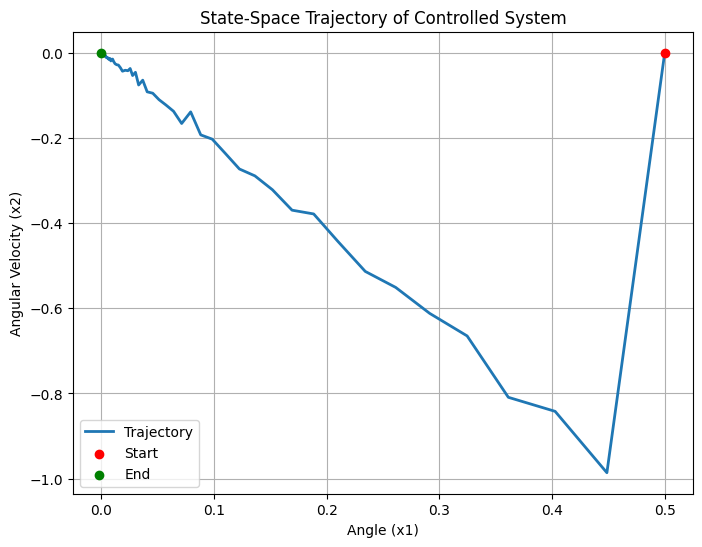

In [3]:
plt.figure(figsize=(8, 6))

# Plot state-space trajectory
plt.plot(x1, x2, label="Trajectory", linewidth=2)
plt.scatter(x1[0], x2[0], color='red', label="Start", zorder=3)
plt.scatter(x1[-1], x2[-1], color='green', label="End", zorder=3)

plt.xlabel("Angle (x1)")
plt.ylabel("Angular Velocity (x2)")
plt.title("State-Space Trajectory of Controlled System")
plt.legend()
plt.grid(True)
plt.show()


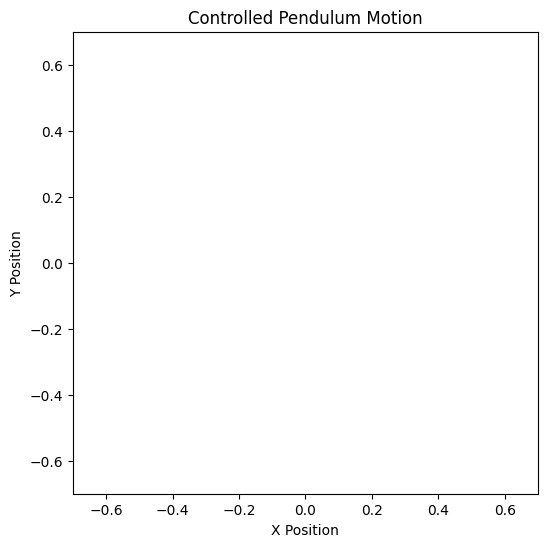

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp

# Define system constants
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# System dynamics f(x)
def f(x):
    x1, x2 = x
    return np.array([x2, A * np.sin(x1) + B * x2])

# Control influence matrix G(x)
def G(x):
    return np.array([[0, 0], [0, 1]])

# Define the control input u(x)
def u(x):
    x1, x2 = x
    term1 = 78 * x1 + 36 * x2
    term2 = x2 * (120 * x1 + 78 * x2) + term1 * (-2.66667 * x2 - 19.62 * np.sin(x1))
    return (-term1) * (np.sqrt(term1**2 * (x1**2 + x2**2) + term2**2) + term2 / (term1**2))

# Closed-loop system dynamics
def closed_loop_dynamics(t, x):
    u_val = u(x)  # Compute control input
    u_val = np.clip(u_val, -200, 200)
    return f(x) + G(x) @ np.array([0, u_val])  # Apply control

# Time span for simulation
t_span = [0, 5]  # Simulate for 5 seconds
t_eval = np.linspace(t_span[0], t_span[1], 200)  # More steps for smooth animation

# Initial condition (angle, angular velocity)
x0 = np.array([0.5, 0.0])  

# Solve the system
sol = solve_ivp(closed_loop_dynamics, t_span, x0, t_eval=t_eval)

# Extract results
t = sol.t
theta, omega = sol.y  # State variables (angle, angular velocity)

# Convert angle to Cartesian coordinates for animation
x_pendulum = l * np.sin(theta)  
y_pendulum = -l * np.cos(theta)  

# ---------------- Animation ---------------- #

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-l - 0.2, l + 0.2)
ax.set_ylim(-l - 0.2, l + 0.2)
ax.set_title("Controlled Pendulum Motion")
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

# Pendulum rod and bob
rod, = ax.plot([], [], 'o-', lw=3, markersize=10)
trace, = ax.plot([], [], 'r--', lw=1)  # Red dashed line for trace
trace_x, trace_y = [], []  # To store trajectory

# Initialize animation
def init():
    rod.set_data([], [])
    trace.set_data([], [])
    return rod, trace

# Update function for animation
def update(frame):
    x, y = x_pendulum[frame], y_pendulum[frame]
    
    # Update rod position
    rod.set_data([0, x], [0, y])
    
    # Update trajectory
    trace_x.append(x)
    trace_y.append(y)
    trace.set_data(trace_x, trace_y)

    return rod, trace

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(t), init_func=init, blit=True, interval=20)

plt.show()

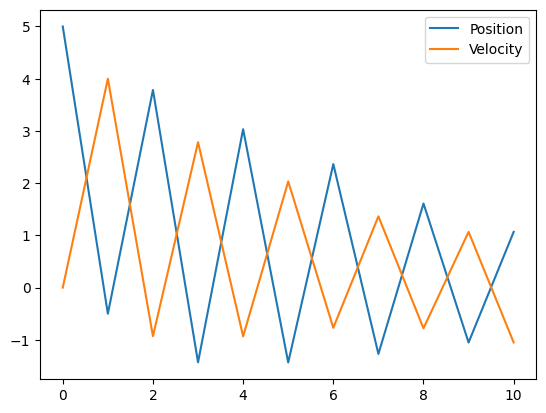

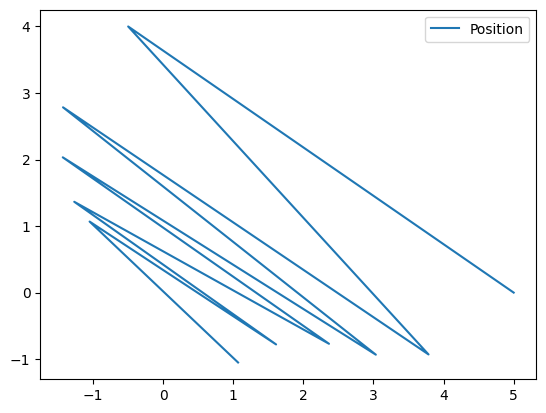

In [14]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define system dynamics: x[k+1] = Ax[k] + Bu[k]

# Constants
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A_val, B_val = -g / l, -b / (m * l**2)

A = np.array([[0.0, 1.0], [1, 0]])
B = np.array([[0.5], [1.0]])
Q = np.eye(2)  # State cost
R = np.eye(1)  # Control cost

N = 10  # Prediction horizon
x_init = np.array([[5.0], [0.0]])  # Initial state

# Define optimization variables
x = cp.Variable((2, N+1))
u = cp.Variable((1, N))

# Define the optimization problem
cost = 0
constraints = [x[:, 0] == x_init[:, 0]]

for k in range(N):
    cost += cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R)
    constraints += [x[:, k+1] == A @ x[:, k] + B @ u[:, k]]
    constraints += [cp.abs(u[:, k]) <= 1]  # Control constraints

# Solve MPC
problem = cp.Problem(cp.Minimize(cost), constraints)
problem.solve()

# Plot results
plt.figure()
plt.plot(x.value[0, :], label="Position")
plt.plot(x.value[1, :], label="Velocity")
plt.legend()
plt.show()

# Plot results
plt.figure()
plt.plot(x.value[0, :], x.value[1, :], label="Position")
plt.legend()
plt.show()


In [5]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Define system dynamics: x[k+1] = Ax[k] + Bu[k]

# Constants
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A_val, B_val = -g / l, -b / (m * l**2)

# Define the system matrices
A = np.array([[0, 1],
              [A_val, B_val]])  # System matrix
B = np.array([[0],
              [1]])  # Input matrix (2x1)

# Define the LQR weight matrices
Q = np.array([[1, 0],
              [0, 1]])  # State cost
R = np.array([[1]])  # Control cost (1x1 for single input)

N = 10  # Prediction horizon
x_init = np.array([[0.5], [0.5]])  # Initial state

# Define optimization variables
x = cp.Variable((2, N+1))
u = cp.Variable((1, N))

# Define the optimization problem
cost = 0
constraints = [x[:, 0] == x_init[:, 0]]

for k in range(N):
    cost += cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R)
    constraints += [x[:, k+1] == A @ x[:, k] + B @ u[:, k]]  # Fix dimensions
    constraints += [cp.abs(u[:, k]) <= 1]  # Control constraints

# Solve MPC
problem = cp.Problem(cp.Minimize(cost), constraints)
problem.solve(solver=cp.OSQP)  # Explicitly use OSQP solver

# Check if the solver found a solution
if x.value is None:
    print("Solver failed to find a solution.")
else:
    # Plot results
    plt.figure()
    plt.plot(x.value[0, :], label="Position")
    plt.plot(x.value[1, :], label="Velocity")
    plt.legend()
    plt.xlabel("Time Step")
    plt.ylabel("State Values")
    plt.title("State Evolution")
    plt.grid()
    plt.show()

    # Plot phase-space trajectory
    plt.figure()
    plt.plot(x.value[0, :], x.value[1, :], label="Phase Space (x vs. v)")
    plt.legend()
    plt.xlabel("Position")
    plt.ylabel("Velocity")
    plt.title("Phase Space Trajectory")
    plt.grid()
    plt.show()


Solver failed to find a solution.


In [1]:
import numpy as np
import do_mpc
from casadi import *
from do_mpc.model import Model
from do_mpc.controller import MPC
from do_mpc.simulator import Simulator
import matplotlib.pyplot as plt

# Create the model
model_type = 'continuous'  # Continuous-time model
model = Model(model_type)

# Define state variables
x1 = model.set_variable('_x', 'x1')  # Position (angle)
x2 = model.set_variable('_x', 'x2')  # Velocity

# Define control input
u = model.set_variable('_u', 'u')

# Define system parameters
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# Define nonlinear system dynamics
f1 = x2
#f2 = A * sin(x1) + B * x2 + u  # Nonlinear pendulum equation with control
f2 = -x1 * (3.14/2  + arctan(5 * x1)) - (5 * x1**2 / (2 * (1 + 25 * x1**2))) + 4 * x2 + 3 * u
    

# Set right-hand side (RHS) of system equations
model.set_rhs('x1', f1)
model.set_rhs('x2', f2)

# Finalize model
model.setup()

In [14]:
mpc = MPC(model)

t_step = 0.5
# Set time step and prediction horizon
mpc.set_param(n_horizon=20, t_step=t_step)

# Define cost function weights
Q = np.diag([1, 1])  # State cost matrix
R = np.diag([0.1])   # Control cost

mpc.set_objective(
    lterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2 + R[0, 0] * u**2,  # Running cost
    mterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2  # Terminal cost (optional)
)

mpc.set_rterm(
    u=0.1  # Adjust this value to balance responsiveness and smoothness
)

# Input constraints (control effort limits)
mpc.bounds['lower', '_u', 'u'] = -10
mpc.bounds['upper', '_u', 'u'] = 10

# Setup optimizer
mpc.setup()

In [ ]:
# Create simulator
simulator = Simulator(model)
simulator.set_param(t_step=t_step)
simulator.setup()

# Set initial condition
x0 = np.array([3, -2])  # Initial angle and velocity
mpc.x0 = x0
simulator.x0 = x0

# Simulate for 100 steps
n_steps = 100
u_list = []
x_list = [x0]

for i in range(n_steps):
    u_cmd = mpc.make_step(x0)  # Solve MPC problem
    x_next = simulator.make_step(u_cmd)  # Simulate system
    u_list.append(u_cmd)
    x_list.append(x_next)
    x0 = x_next  # Update state

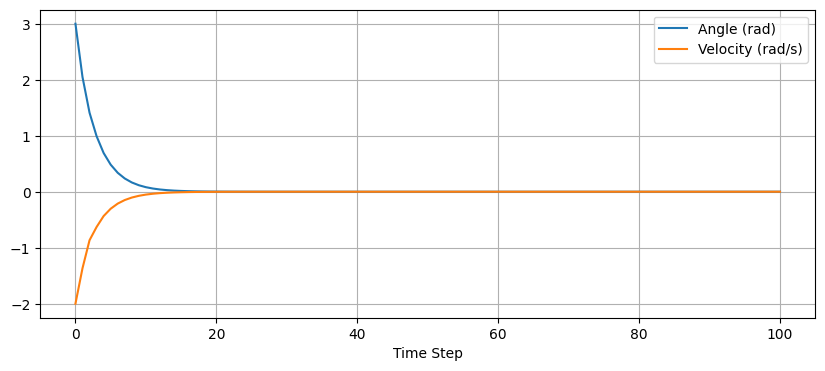

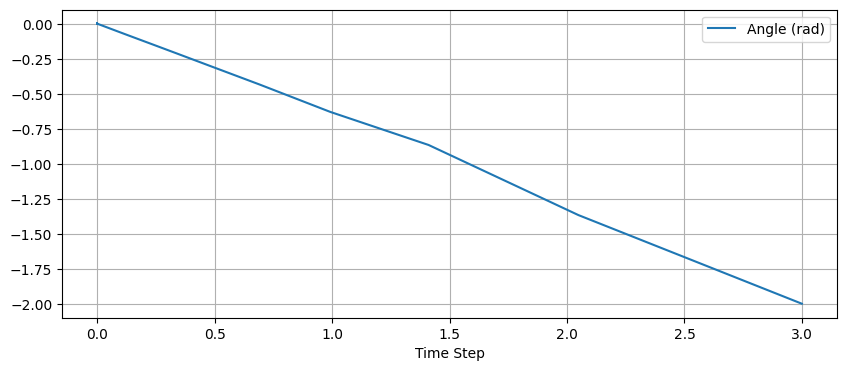

In [16]:
# Convert results to NumPy array
x_list = np.array([np.array(x).flatten() for x in x_list])

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(x_list[:, 0], label='Angle (rad)')
plt.plot(x_list[:, 1], label='Velocity (rad/s)')
plt.xlabel("Time Step")
plt.legend()
plt.grid()
plt.show()

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(x_list[:, 0], x_list[:, 1], label='Angle (rad)')
plt.xlabel("Time Step")
plt.legend()
plt.grid()
plt.show()